# Notebook 01 — Analyse Exploratoire des Données (EDA)

| | |
|---|---|
| **Projet** | Application Intelligente de Scoring Client |
| **Entreprise** | Orus Services — filiale Salafin, Bank of Africa |
| **Auteure** | Fatima Zahra Ait Lamine |
| **Encadrante** | Mme. Kaoutar Loutfi |
| **Année** | PFE 2025 |

---

## Objectif de ce notebook

Avant d'entraîner un seul modèle, on explore les données brutes pour **comprendre ce qu'elles contiennent, détecter leurs problèmes, et justifier chaque décision de prétraitement**.

Ce notebook répond aux questions suivantes, dans l'ordre :

| # | Question | Section |
|---|---|---|
| 1 | Quelle est la structure du dataset ? (dimensions, types, signification des colonnes) | §2 |
| 2 | Y a-t-il un déséquilibre de classes ? À quel point est-il problématique ? | §3 |
| 3 | Quelles colonnes ont des valeurs manquantes, et pourquoi ? | §4 |
| 4 | Y a-t-il des outliers ? Sont-ils réels ou des erreurs ? | §5 |
| 5 | Certaines valeurs sont-elles des codes sentinelles (ex : `98`) plutôt que de vraies données ? | §6 |
| 6 | Quelles features sont les plus liées au défaut de paiement ? | §7 |
| 7 | Comment les distributions des features se comportent-elles selon la classe ? | §8 |
| 8 | Comment construire logiquement une target à 3 niveaux de risque ? | §9 |

> **Principe :** chaque visualisation est suivie d'une conclusion qui détermine une décision concrète dans le notebook 02 (Preprocessing).


---
## 1. Imports et configuration globale

On importe les bibliothèques nécessaires et on configure un style graphique cohérent pour tout le notebook.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Style graphique unifié ──────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

# Palette couleurs métier (vert=faible risque, orange=moyen, rouge=élevé)
COLORS = {
    'FAIBLE':   '#27ae60',
    'MOYEN':    '#e67e22',
    'ELEVE':    '#e74c3c',
    'default':  '#3498db',
    'non_def':  '#2ecc71',
}

print("✓ Imports OK")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")

✓ Imports OK
  pandas  2.3.3
  numpy   2.3.3


---
## 2. Chargement du dataset et structure générale

### 2.1 Source des données

Le dataset utilisé est **Give Me Some Credit** — Kaggle Competition (2011), fichier `cs-training.csv`.  
Il contient des informations financières sur des clients américains ainsi qu'un indicateur de défaut de paiement sur 2 ans.

On utilise ce dataset parce qu'il est :
- **Représentatif** du scoring bancaire (features similaires à celles du projet Orus)
- **Volumineux** (150 000 lignes) — suffisant pour entraîner des modèles robustes
- **Annoté** — la variable cible `SeriousDlqin2yrs` est disponible
- **Anonymisé** — aucune donnée personnelle réelle


In [25]:
# Chargement — la première colonne est un index numérique sans label
df = pd.read_csv('../data/cs-training.csv', index_col=0)

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Mémoire    : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dimensions : 150,000 lignes × 11 colonnes
Mémoire    : 13.7 MB


### 2.2 Signification des colonnes

Avant d'analyser quoi que ce soit, il faut comprendre ce que chaque colonne représente dans un contexte métier bancaire.


In [26]:
column_descriptions = {
    'SeriousDlqin2yrs':                       'TARGET — Défaut de paiement (90+ jours) dans les 2 prochaines années (0=Non, 1=Oui)',
    'RevolvingUtilizationOfUnsecuredLines':    "Taux d'utilisation des lignes de crédit renouvelables (cartes, lignes perso) - entre 0 et 1 normalement",
    'age':                                     'Âge du client en années',
    'NumberOfTime30-59DaysPastDueNotWorse':    'Nb de fois en retard de 30-59 jours (sans dépasser) sur les 2 dernières années',
    'DebtRatio':                               "Ratio charges mensuelles / revenus mensuels (taux d'endettement)",
    'MonthlyIncome':                           'Revenus mensuels en USD',
    'NumberOfOpenCreditLinesAndLoans':         'Nb de lignes de crédit et prêts ouverts',
    'NumberOfTimes90DaysLate':                 'Nb de fois en retard de 90 jours ou plus sur les 2 dernières années',
    'NumberRealEstateLoansOrLines':            'Nb de prêts immobiliers ou lignes de crédit hypothécaire',
    'NumberOfTime60-89DaysPastDueNotWorse':    'Nb de fois en retard de 60-89 jours (sans dépasser) sur les 2 dernières années',
    'NumberOfDependents':                      'Nb de personnes à charge (hors conjoint)',
}

desc_df = pd.DataFrame.from_dict(column_descriptions, orient='index', columns=['Description'])
desc_df.index.name = 'Colonne'
desc_df

,Description
Colonne,
SeriousDlqin2yrs,TARGET — Défaut de paiement (90+ jours) dans l...
RevolvingUtilizationOfUnsecuredLines,Taux d'utilisation des lignes de crédit renouv...
age,Âge du client en années
NumberOfTime30-59DaysPastDueNotWorse,Nb de fois en retard de 30-59 jours (sans dépa...
DebtRatio,Ratio charges mensuelles / revenus mensuels (t...
MonthlyIncome,Revenus mensuels en USD
NumberOfOpenCreditLinesAndLoans,Nb de lignes de crédit et prêts ouverts
NumberOfTimes90DaysLate,Nb de fois en retard de 90 jours ou plus sur l...
NumberRealEstateLoansOrLines,Nb de prêts immobiliers ou lignes de crédit hy...


In [27]:
# Aperçu des premières lignes
print("Aperçu des 5 premières lignes :")
df.head()

Aperçu des 5 premières lignes :


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [28]:
# Types de données et valeurs manquantes — vue synthétique
info_df = pd.DataFrame({
    'Type'              : df.dtypes.astype(str),
    'Non-null'          : df.count(),
    'Manquant (n)'      : df.isnull().sum(),
    'Manquant (%)'      : (df.isnull().sum() / len(df) * 100).round(2),
    'Min'               : df.min(),
    'Max'               : df.max(),
    'Médiane'           : df.median(),
})
info_df

,Type,Non-null,Manquant (n),Manquant (%),Min,Max,Médiane
SeriousDlqin2yrs,int64,150000,0,0.00,0.0,1.0,0.000000
RevolvingUtilizationOfUnsecuredLines,float64,150000,0,0.00,0.0,50708.0,0.154181
age,int64,150000,0,0.00,0.0,109.0,52.000000
NumberOfTime30-59DaysPastDueNotWorse,int64,150000,0,0.00,0.0,98.0,0.000000
DebtRatio,float64,150000,0,0.00,0.0,329664.0,0.366508
MonthlyIncome,float64,120269,29731,19.82,0.0,3008750.0,5400.000000
NumberOfOpenCreditLinesAndLoans,int64,150000,0,0.00,0.0,58.0,8.000000
NumberOfTimes90DaysLate,int64,150000,0,0.00,0.0,98.0,0.000000
NumberRealEstateLoansOrLines,int64,150000,0,0.00,0.0,54.0,1.000000
NumberOfTime60-89DaysPastDueNotWorse,int64,150000,0,0.00,0.0,98.0,0.000000


### 2.3 Correspondance avec les features du projet Orus

Le dataset Kaggle utilise des colonnes différentes de celles définies dans le cahier des charges. Voici le mapping qui sera appliqué lors du preprocessing :

| Colonne Kaggle | Colonne projet Orus | Logique |
|---|---|---|
| `MonthlyIncome` | `revenus_mensuels` | Direct |
| `DebtRatio × MonthlyIncome` | `charges_mensuelles` | Calculé |
| `DebtRatio` | `taux_endettement` | Direct |
| Colonnes late payments combinées | `historique_financier` (BON/MOYEN/MAUVAIS) | Règle métier |
| `age` | `age` | Direct |
| `NumberOfOpenCreditLinesAndLoans` + `NumberRealEstateLoansOrLines` | proxy `situation_pro` | Approximation |

> **Note :** Ce mapping sera implémenté dans le notebook 02. L'EDA porte sur les colonnes Kaggle d'origine.


---
## 3. Déséquilibre de classes — le problème central

### 3.1 Pourquoi c'est un problème

En scoring bancaire, les défauts de paiement sont **rares mais coûteux**.  
Un modèle naïf qui prédit toujours "pas de défaut" obtient une accuracy de ~93% — mais est inutile dans la pratique, car il ne détecte aucun cas à risque.

C'est pourquoi on mesure le déséquilibre avant tout, et on choisit des métriques adaptées (ROC-AUC, recall) plutôt que l'accuracy brute.


In [29]:
counts      = df['SeriousDlqin2yrs'].value_counts().sort_index()
proportions = df['SeriousDlqin2yrs'].value_counts(normalize=True).sort_index() * 100

print("Distribution de la variable cible `SeriousDlqin2yrs` :")
print(f"  Classe 0 — Non-défaut : {counts[0]:>7,} clients  ({proportions[0]:.1f}%)")
print(f"  Classe 1 — Défaut     : {counts[1]:>7,} clients  ({proportions[1]:.1f}%)")
print()
print(f"  → Ratio de déséquilibre : {counts[0]/counts[1]:.0f} clients sains pour 1 défaut")
print(f"  → Un modèle naïf (always-0) atteindrait {proportions[0]:.1f}% d'accuracy — mais 0% de recall sur les défauts")

Distribution de la variable cible `SeriousDlqin2yrs` :
  Classe 0 — Non-défaut : 139,974 clients  (93.3%)
  Classe 1 — Défaut     :  10,026 clients  (6.7%)

  → Ratio de déséquilibre : 14 clients sains pour 1 défaut
  → Un modèle naïf (always-0) atteindrait 93.3% d'accuracy — mais 0% de recall sur les défauts


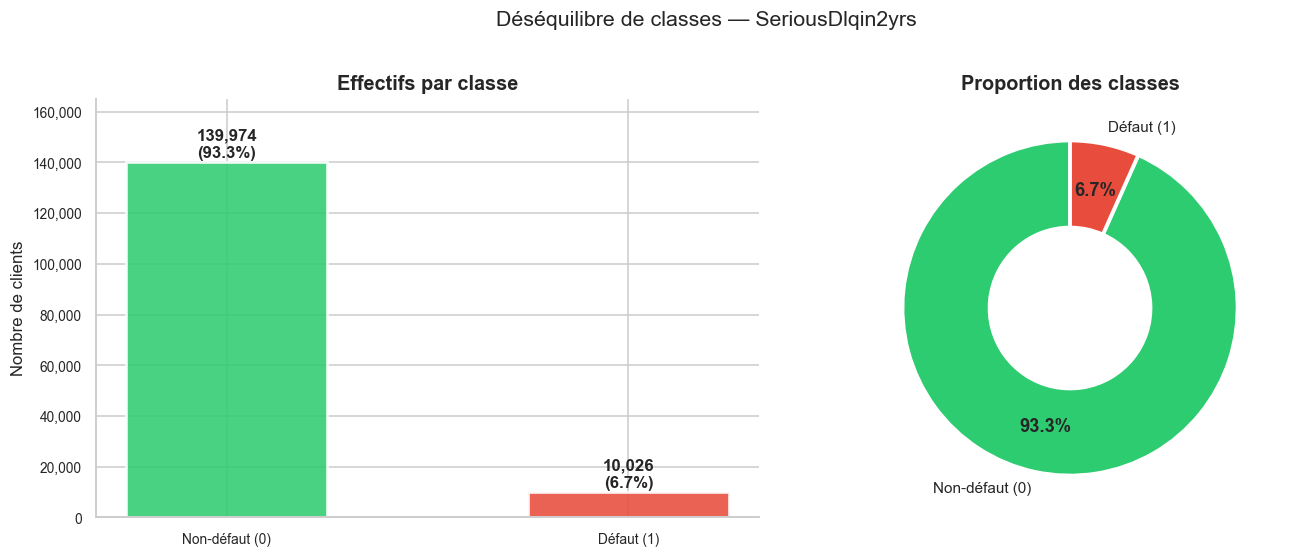

Figure sauvegardée : ./figures/fig_01_class_imbalance.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Barplot ────────────────────────────────────────────────
ax1 = axes[0]
labels = ['Non-défaut (0)', 'Défaut (1)']
bar_colors = [COLORS['non_def'], COLORS['ELEVE']]
bars = ax1.bar(labels, counts.values, color=bar_colors, alpha=0.88,
               edgecolor='white', linewidth=1.8, width=0.5)
for bar, val, pct in zip(bars, counts.values, proportions.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 800,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_title('Effectifs par classe')
ax1.set_ylabel('Nombre de clients')
ax1.set_ylim(0, counts[0] * 1.18)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.spines[['top', 'right']].set_visible(False)

# ── Donut ──────────────────────────────────────────────────
ax2 = axes[1]
wedge_props = dict(width=0.52, edgecolor='white', linewidth=2.5)
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=labels,
    colors=bar_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.72,
    wedgeprops=wedge_props,
    textprops={'fontsize': 10},
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax2.set_title('Proportion des classes')

plt.suptitle('Déséquilibre de classes — SeriousDlqin2yrs', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('./figures/fig_01_class_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : ./figures/fig_01_class_imbalance.png")

### 3.2 Conséquences et décisions

Le déséquilibre ~**93% / 7%** a deux implications directes :

**1 — Métrique d'évaluation**  
L'accuracy est trompeuse. On utilisera **ROC-AUC** comme métrique principale, complétée par le **recall sur la classe défaut** (priorité métier : mieux vaut faux-positif que faux-négatif en scoring de risque).

**2 — Stratégie d'équilibrage** (décision notebook 02)
- `class_weight='balanced'` dans tous les algorithmes qui le supportent (Logistic Regression, Random Forest, XGBoost)
- **SMOTE** (Synthetic Minority Over-sampling Technique) appliqué **uniquement sur le train set**, jamais sur la validation ni le test — sinon on évalue sur des données synthétiques et on surestime les performances


---
## 4. Analyse des valeurs manquantes

### 4.1 Quelles colonnes sont concernées ?

Deux colonnes présentent des valeurs manquantes. On mesure leur ampleur et on vérifie si l'absence de valeur est **aléatoire** (MCAR — Missing Completely At Random) ou **liée à la cible** (MAR — Missing At Random).

Cette distinction est importante : si les valeurs manquantes sont liées au risque de défaut, la suppression des lignes introduirait un biais.


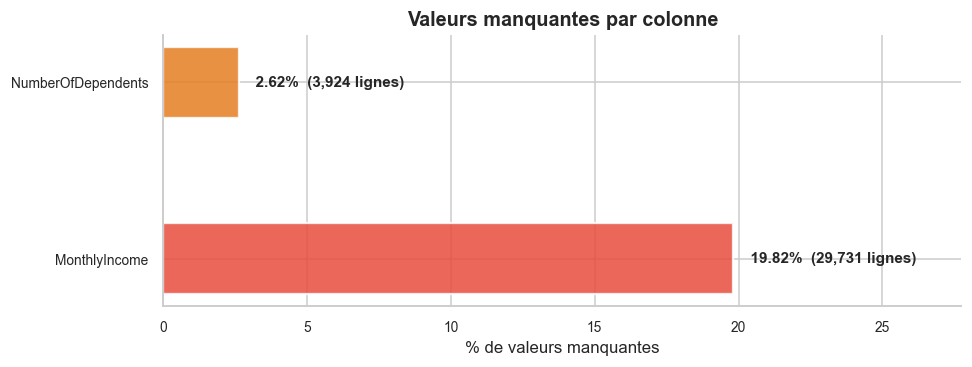

In [31]:
missing      = df.isnull().sum()
missing      = missing[missing > 0].sort_values(ascending=False)
missing_pct  = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 3.5))
bar_colors_m = [COLORS['ELEVE'] if v > 10 else COLORS['MOYEN'] for v in missing_pct.values]
bars = ax.barh(missing.index, missing_pct.values,
               color=bar_colors_m, alpha=0.85, edgecolor='white', linewidth=1.5, height=0.4)
for bar, pct, n in zip(bars, missing_pct.values, missing.values):
    ax.text(pct + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'  {pct}%  ({n:,} lignes)',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Valeurs manquantes par colonne')
ax.set_xlim(0, missing_pct.max() * 1.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('./figures/fig_02_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.2 Les valeurs manquantes sont-elles liées au défaut ?

On compare le taux de défaut entre les clients avec et sans valeur renseignée. Si les taux sont similaires, les données manquent de façon aléatoire (MCAR). Sinon, l'absence est elle-même informative (MAR).


In [32]:
for col in missing.index:
    rate_present = df[df[col].notna()]['SeriousDlqin2yrs'].mean() * 100
    rate_missing = df[df[col].isna()]['SeriousDlqin2yrs'].mean() * 100
    diff = rate_missing - rate_present

    print(f"─── {col} ───")
    print(f"  Taux de défaut — valeur présente : {rate_present:.2f}%")
    print(f"  Taux de défaut — valeur manquante: {rate_missing:.2f}%")
    print(f"  Différence                        : {diff:+.2f} points")
    print()

─── MonthlyIncome ───
  Taux de défaut — valeur présente : 6.95%
  Taux de défaut — valeur manquante: 5.61%
  Différence                        : -1.33 points

─── NumberOfDependents ───
  Taux de défaut — valeur présente : 6.74%
  Taux de défaut — valeur manquante: 4.56%
  Différence                        : -2.18 points



### 4.3 Conclusion et décision

| Colonne | % manquant | Type de manque | Décision |
|---|---|---|---|
| `MonthlyIncome` | ~19.8% | MAR probable (lié au profil du client) | Imputation par la **médiane** (robuste aux outliers de revenus) |
| `NumberOfDependents` | ~2.6% | MCAR probable | Imputation par la **médiane** |

> **Pourquoi la médiane et pas la moyenne ?**  
> Les revenus et le nombre de dépendants ont des distributions asymétriques (skewed). La moyenne est tirée vers les valeurs extrêmes ; la médiane représente mieux le "client typique".  

> **Pourquoi ne pas supprimer les lignes ?**  
> Supprimer 19.8% du dataset (≈30 000 lignes) réduirait significativement la quantité de données d'entraînement et introduirait un biais si les lignes manquantes ne sont pas aléatoires.


---
## 5. Analyse des outliers

### 5.1 Identification

Les outliers extrêmes peuvent dégrader les performances des modèles linéaires et affecter les règles de split des arbres de décision. On distingue deux catégories :

- **Erreurs de saisie évidentes** : `age = 0` — un client d'âge zéro n'existe pas → **suppression**
- **Valeurs aberrantes** : `DebtRatio = 329 664` — un taux d'endettement > 100% est déjà problématique, 329 664 est physiquement impossible → **écrêtage (capping)**

On commence par visualiser les boxplots qui rendent les outliers immédiatement visibles.


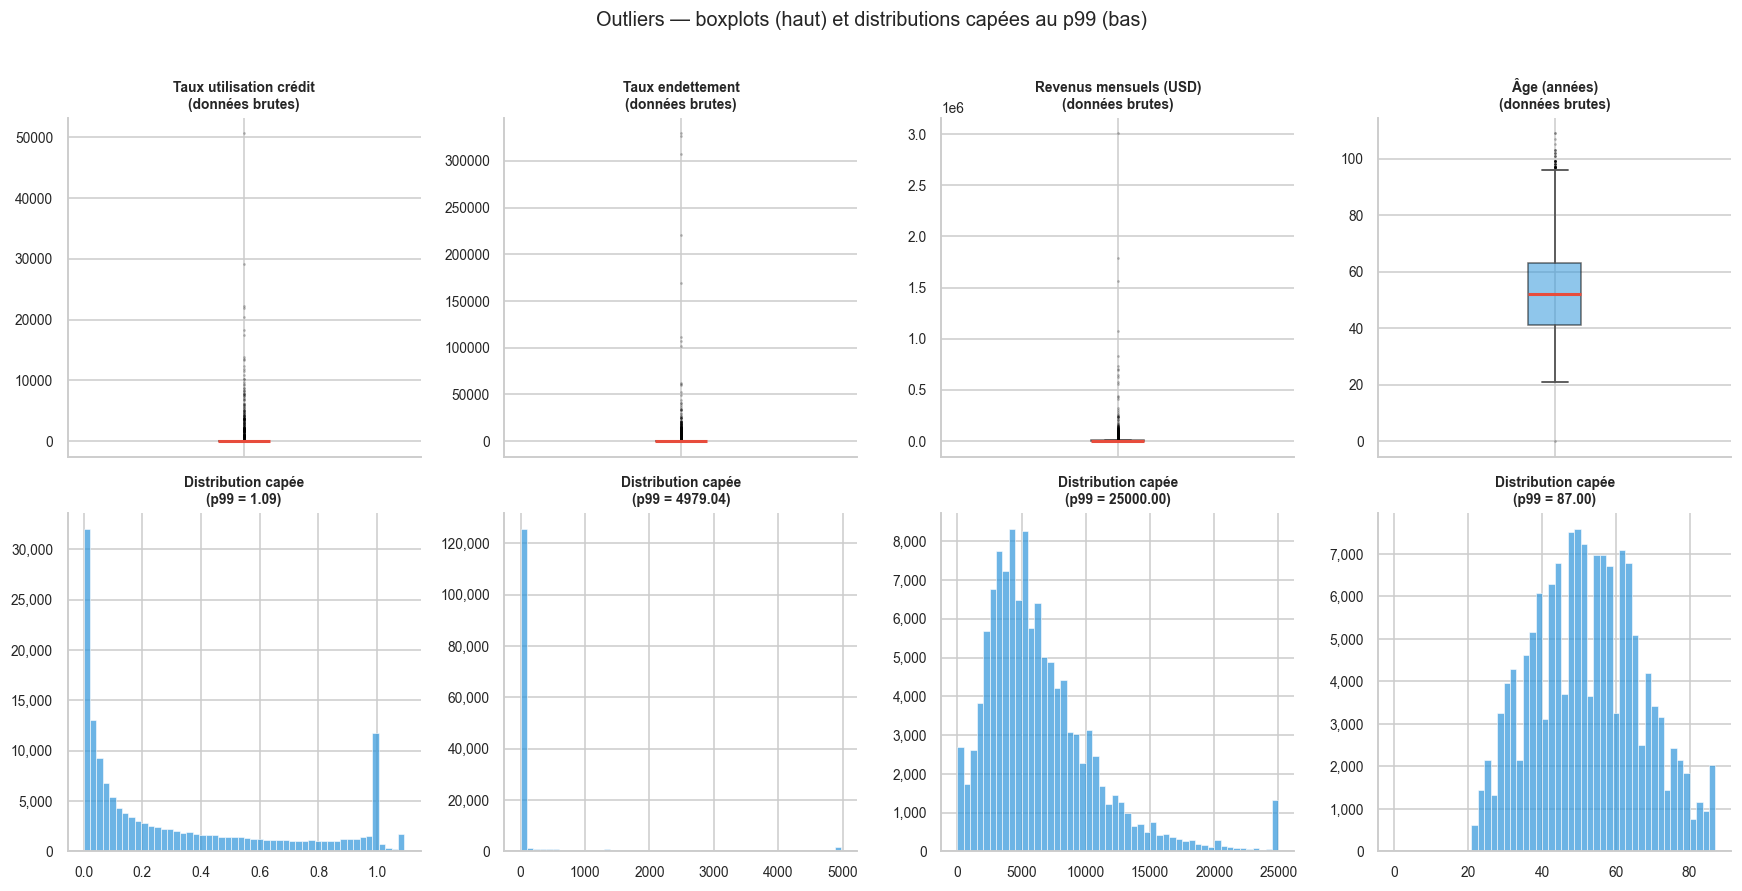

Figure sauvegardée : ./figures/fig_03_outliers.png


In [33]:
# Variables continues à inspecter
continuous_vars = {
    'RevolvingUtilizationOfUnsecuredLines': 'Taux utilisation crédit',
    'DebtRatio'                           : 'Taux endettement',
    'MonthlyIncome'                       : 'Revenus mensuels (USD)',
    'age'                                 : 'Âge (années)',
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (col, label) in enumerate(continuous_vars.items()):
    data = df[col].dropna()

    # ── Boxplot brut ──────────────────────────────────────
    ax_box = axes[0, i]
    bp = ax_box.boxplot(data, vert=True, patch_artist=True,
                        boxprops    =dict(facecolor='#3498db', alpha=0.55),
                        medianprops =dict(color='#e74c3c', linewidth=2),
                        whiskerprops=dict(color='#555', linewidth=1.2),
                        capprops    =dict(color='#555', linewidth=1.2),
                        flierprops  =dict(marker='.', markersize=1.5, alpha=0.25, color='gray'))
    ax_box.set_title(f'{label}\n(données brutes)', fontsize=9)
    ax_box.set_xticklabels([])
    ax_box.spines[['top', 'right']].set_visible(False)

    # ── Histogramme capé p99 ──────────────────────────────
    ax_hist = axes[1, i]
    p99     = data.quantile(0.99)
    capped  = data.clip(upper=p99)
    ax_hist.hist(capped, bins=50, color='#3498db', alpha=0.72,
                 edgecolor='white', linewidth=0.5)
    ax_hist.set_title(f'Distribution capée\n(p99 = {p99:.2f})', fontsize=9)
    ax_hist.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax_hist.spines[['top', 'right']].set_visible(False)

plt.suptitle('Outliers — boxplots (haut) et distributions capées au p99 (bas)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./figures/fig_03_outliers.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : ./figures/fig_03_outliers.png")

**Lecture des boxplots :** Les points gris au-dessus des moustaches sont des outliers détectés par la méthode IQR.  
Pour `DebtRatio` et `RevolvingUtilizationOfUnsecuredLines`, les outliers s'étendent vers des valeurs extrêmes — la visualisation capée au p99 révèle la vraie distribution sous-jacente.


In [34]:
# Quantification des outliers extrêmes
print("=" * 65)
print("QUANTIFICATION DES OUTLIERS PAR COLONNE")
print("=" * 65)

for col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']:
    data = df[col].dropna()
    p99  = data.quantile(0.99)
    p01  = data.quantile(0.01)
    n_above_p99 = (data > p99).sum()
    n_below_p01 = (data < p01).sum()
    pct_above   = n_above_p99 / len(data) * 100

    print(f"\n{col}")
    print(f"  Valeur min brute : {data.min():>14,.2f}")
    print(f"  P01              : {p01:>14,.2f}")
    print(f"  P99              : {p99:>14,.2f}")
    print(f"  Valeur max brute : {data.max():>14,.2f}")
    print(f"  Lignes > P99     : {n_above_p99:>6,} ({pct_above:.2f}%)")

# Cas particulier : age = 0
n_age_zero = (df['age'] == 0).sum()
print(f"\nage == 0 : {n_age_zero} ligne(s) — erreur de saisie → sera supprimée")

QUANTIFICATION DES OUTLIERS PAR COLONNE

RevolvingUtilizationOfUnsecuredLines
  Valeur min brute :           0.00
  P01              :           0.00
  P99              :           1.09
  Valeur max brute :      50,708.00
  Lignes > P99     :  1,500 (1.00%)

DebtRatio
  Valeur min brute :           0.00
  P01              :           0.00
  P99              :       4,979.04
  Valeur max brute :     329,664.00
  Lignes > P99     :  1,500 (1.00%)

MonthlyIncome
  Valeur min brute :           0.00
  P01              :           0.00
  P99              :      25,000.00
  Valeur max brute :   3,008,750.00
  Lignes > P99     :  1,168 (0.97%)

age == 0 : 1 ligne(s) — erreur de saisie → sera supprimée


### 5.2 Décision de traitement

| Colonne | Problème | Décision notebook 02 |
|---|---|---|
| `age == 0` | Erreur de saisie évidente | Suppression de la ligne |
| `DebtRatio` max = 329 664 | Valeur physiquement impossible | Capping au **percentile 99** |
| `RevolvingUtilizationOfUnsecuredLines` max = 50 708 | Taux d'utilisation > 1 déjà anormal | Capping au **percentile 99** |
| `MonthlyIncome` | Queues longues mais réalistes (hauts revenus) | Capping au **percentile 99** |

> **Pourquoi le capping et pas la suppression ?**  
> Le capping remplace les valeurs aberrantes par la valeur au p99, ce qui élimine leur influence disproportionnée sur le modèle tout en conservant toutes les lignes. Supprimer ces lignes ferait perdre des informations utiles contenues dans les autres colonnes.

> **Pourquoi le p99 et pas le p95 ou p100 ?**  
> Le p99 capture 99% de la distribution réelle. Les 1% restants sont très probablement des erreurs ou des cas atypiques non représentatifs. Le p95 serait trop agressif sur des données bancaires qui ont naturellement des queues longues.


---
## 6. Valeurs sentinelles — le problème du "98"

### 6.1 Qu'est-ce qu'une valeur sentinelle ?

Dans certains datasets, une valeur numérique spéciale est utilisée pour **coder une donnée manquante** plutôt que de laisser un `NaN`. C'est une mauvaise pratique courante dans les anciens systèmes.

Ici, la valeur `98` apparaît dans les colonnes de retards de paiement. Un client avec 98 retards de 90 jours est impossible dans la réalité (2 ans = 24 mois max). Il s'agit d'un **code "donnée inconnue"** et non d'une vraie valeur.

Si on la traite comme une vraie valeur, le modèle croirait que ces clients ont eu 98 retards — ce qui fausserait complètement ses prédictions.


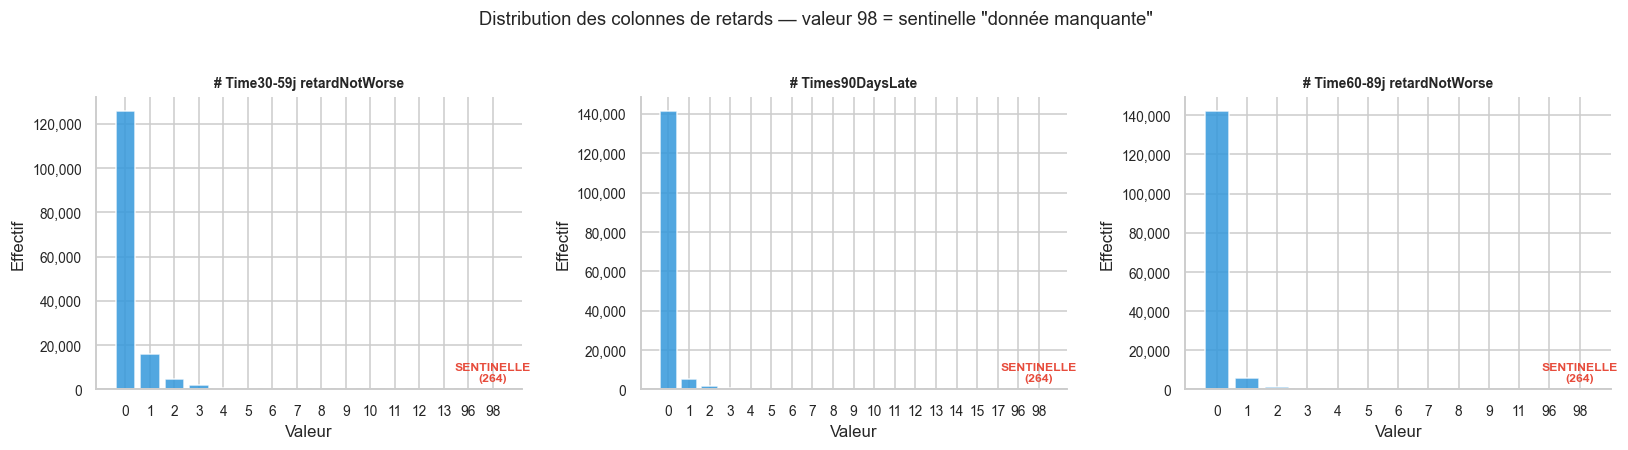

Figure sauvegardée : ./figures/fig_04_sentinel_values.png


In [35]:
delay_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, delay_cols):
    vc = df[col].value_counts().sort_index()
    # Séparer valeurs normales et sentinelle 98
    normal   = vc[vc.index != 98]
    sentinel = vc[vc.index == 98] if 98 in vc.index else pd.Series(dtype=int)

    bar_colors_s = [COLORS['ELEVE'] if idx == 98 else COLORS['default']
                    for idx in vc.index]
    bars = ax.bar(vc.index.astype(str), vc.values,
                  color=bar_colors_s, alpha=0.85, edgecolor='white')

    # Annoter la barre 98
    if 98 in vc.index:
        idx_98 = list(vc.index).index(98)
        ax.text(idx_98, vc.iloc[idx_98] + vc.max() * 0.02,
                f'SENTINELLE\n({vc[98]:,})', ha='center', va='bottom',
                color=COLORS['ELEVE'], fontsize=8, fontweight='bold')

    ax.set_title(col.replace('NumberOf', '# ').replace('DaysPastDue', 'j retard'), fontsize=9)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Effectif')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribution des colonnes de retards — valeur 98 = sentinelle "donnée manquante"',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('./figures/fig_04_sentinel_values.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : ./figures/fig_04_sentinel_values.png")

In [36]:
# Identifier les lignes "sentinelles"
mask_98 = (df[delay_cols] == 98).any(axis=1)
mask_all3 = (df[delay_cols] == 98).all(axis=1)

print(f"Lignes avec 98 dans au moins 1 colonne de retard : {mask_98.sum():,}")
print(f"Lignes avec 98 dans les 3 colonnes simultanément : {mask_all3.sum():,}")
print()

# Comportement de ces lignes par rapport à la target
print("Taux de défaut des lignes sentinelles vs reste du dataset :")
rate_sentinel = df[mask_98]['SeriousDlqin2yrs'].mean() * 100
rate_normal   = df[~mask_98]['SeriousDlqin2yrs'].mean() * 100
print(f"  Lignes avec 98     : {rate_sentinel:.1f}%")
print(f"  Reste du dataset   : {rate_normal:.1f}%")
print()
print("Exemple de lignes avec la valeur sentinelle :")
df[mask_98][delay_cols + ['SeriousDlqin2yrs']].head(5)

Lignes avec 98 dans au moins 1 colonne de retard : 264
Lignes avec 98 dans les 3 colonnes simultanément : 264

Taux de défaut des lignes sentinelles vs reste du dataset :
  Lignes avec 98     : 54.2%
  Reste du dataset   : 6.6%

Exemple de lignes avec la valeur sentinelle :


,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,SeriousDlqin2yrs
1734,98,98,98,1
2287,98,98,98,0
3885,98,98,98,0
4418,98,98,98,0
4706,98,98,98,0


### 6.2 Décision

**Décision (notebook 02) :** Remplacer les `98` par `NaN`, puis les imputer avec la **médiane** de chaque colonne.

> On ne supprime pas ces lignes car elles contiennent d'autres colonnes valides (revenus, âge, etc.) qui ont de la valeur pour le modèle.


---
## 7. Analyse des corrélations

### 7.1 Corrélations avec la variable cible

On mesure la corrélation linéaire (Pearson) de chaque feature avec `SeriousDlqin2yrs`.  
Une corrélation élevée indique un bon pouvoir prédictif *linéaire*. Attention : une corrélation faible ne signifie pas que la feature est inutile — les modèles non-linéaires (Random Forest, XGBoost) peuvent exploiter des relations plus complexes.


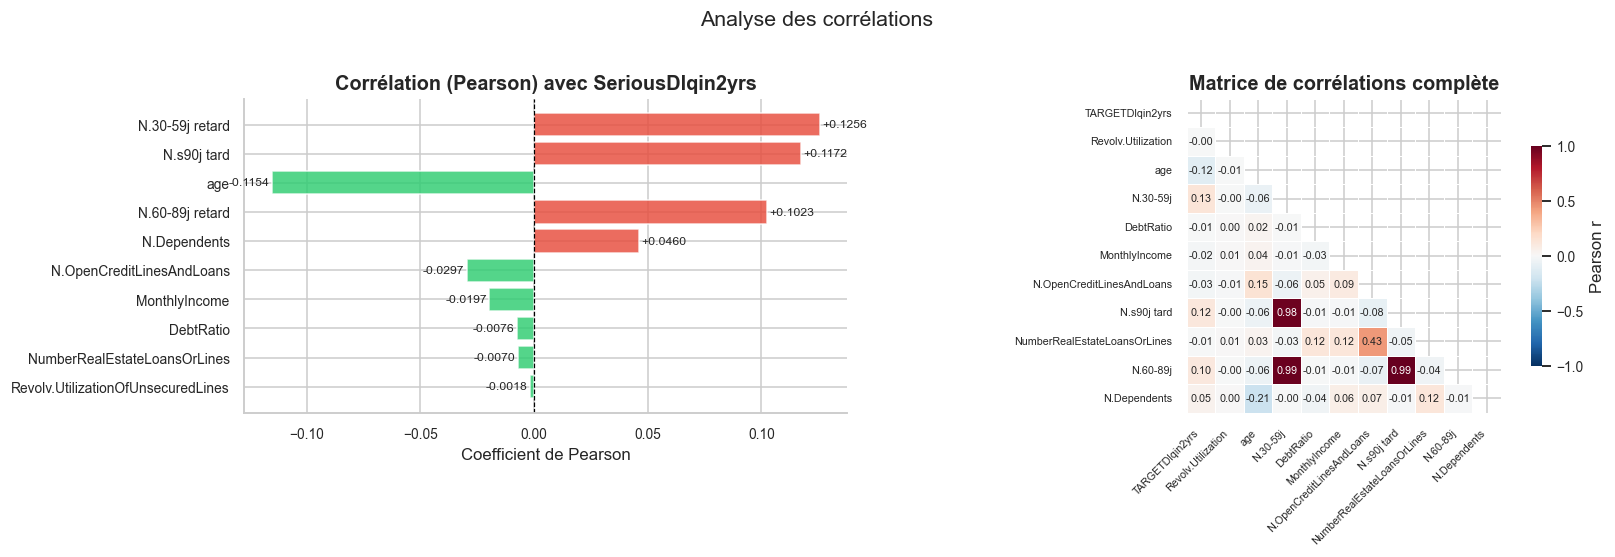

Figure sauvegardée : ./figures/fig_05_correlations.png


In [37]:
corr_target = (df.corr()['SeriousDlqin2yrs']
                 .drop('SeriousDlqin2yrs')
                 .sort_values(key=abs, ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Corrélations avec la target ───────────────────────────
ax1 = axes[0]
colors_corr = [COLORS['ELEVE'] if v > 0 else COLORS['non_def'] for v in corr_target.values]
bars = ax1.barh(range(len(corr_target)), corr_target.values,
                color=colors_corr, alpha=0.82, edgecolor='white', linewidth=1)
ax1.set_yticks(range(len(corr_target)))
short_labels = [c.replace('NumberOfTime', 'N.').replace('NumberOf', 'N.')
                  .replace('Revolving', 'Revolv.')
                  .replace('DaysPastDueNotWorse', 'j retard')
                  .replace('DaysLate', 'j tard')
                for c in corr_target.index]
ax1.set_yticklabels(short_labels, fontsize=9)
ax1.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Corrélation (Pearson) avec SeriousDlqin2yrs')
ax1.set_xlabel('Coefficient de Pearson')
ax1.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(corr_target.values):
    ax1.text(v + (0.001 if v >= 0 else -0.001), i,
             f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# ── Heatmap matrice complète ──────────────────────────────
ax2 = axes[1]
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
short_cols = [c.replace('NumberOfTime', 'N.').replace('NumberOf', 'N.')
               .replace('Revolving', 'Revolv.').replace('Serious', 'TARGET')
               .replace('DaysPastDueNotWorse', 'j').replace('DaysLate', 'j tard')
               .replace('OfUnsecuredLines', '') for c in corr_matrix.columns]
sns.heatmap(corr_matrix, mask=mask, ax=ax2,
            xticklabels=short_cols, yticklabels=short_cols,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.4, square=True,
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'})
ax2.set_title('Matrice de corrélations complète')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=7)

plt.suptitle('Analyse des corrélations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('./figures/fig_05_correlations.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : ./figures/fig_05_correlations.png")

### 7.2 Lecture des résultats

**Features les plus corrélées avec le défaut :**

| Feature | Sens | Interprétation métier |
|---|---|---|
| Colonnes retards (`90 jours`, `30-59 jours`, `60-89 jours`) | Positif | Plus de retards passés → plus de risque de défaut futur |
| `RevolvingUtilizationOfUnsecuredLines` | Positif | Taux d'utilisation élevé → tension financière → risque plus élevé |
| `DebtRatio` | Positif | Taux d'endettement élevé → capacité de remboursement réduite |
| `MonthlyIncome` | Négatif | Revenus plus élevés → risque de défaut plus faible |
| `age` | Négatif | Clients plus âgés → historique plus stable → risque moindre (en général) |

> **Important :** Les corrélations linéaires sont faibles sur ce dataset, ce qui est normal en scoring bancaire. Les relations sont souvent non-linéaires (ex : au-dessus d'un certain seuil d'endettement, le risque explose). C'est précisément pourquoi on utilisera des modèles non-linéaires comme **Random Forest** et **XGBoost**.


---
## 8. Distribution des features par classe

Un bon feature discriminant doit avoir des distributions **différentes** entre la classe 0 (non-défaut) et la classe 1 (défaut). On superpose les distributions KDE pour visualiser cet écart.

Si les distributions se chevauchent beaucoup, la feature sera moins utile seule — mais elle peut contribuer en combinaison avec d'autres (ce que les modèles d'ensemble exploitent).


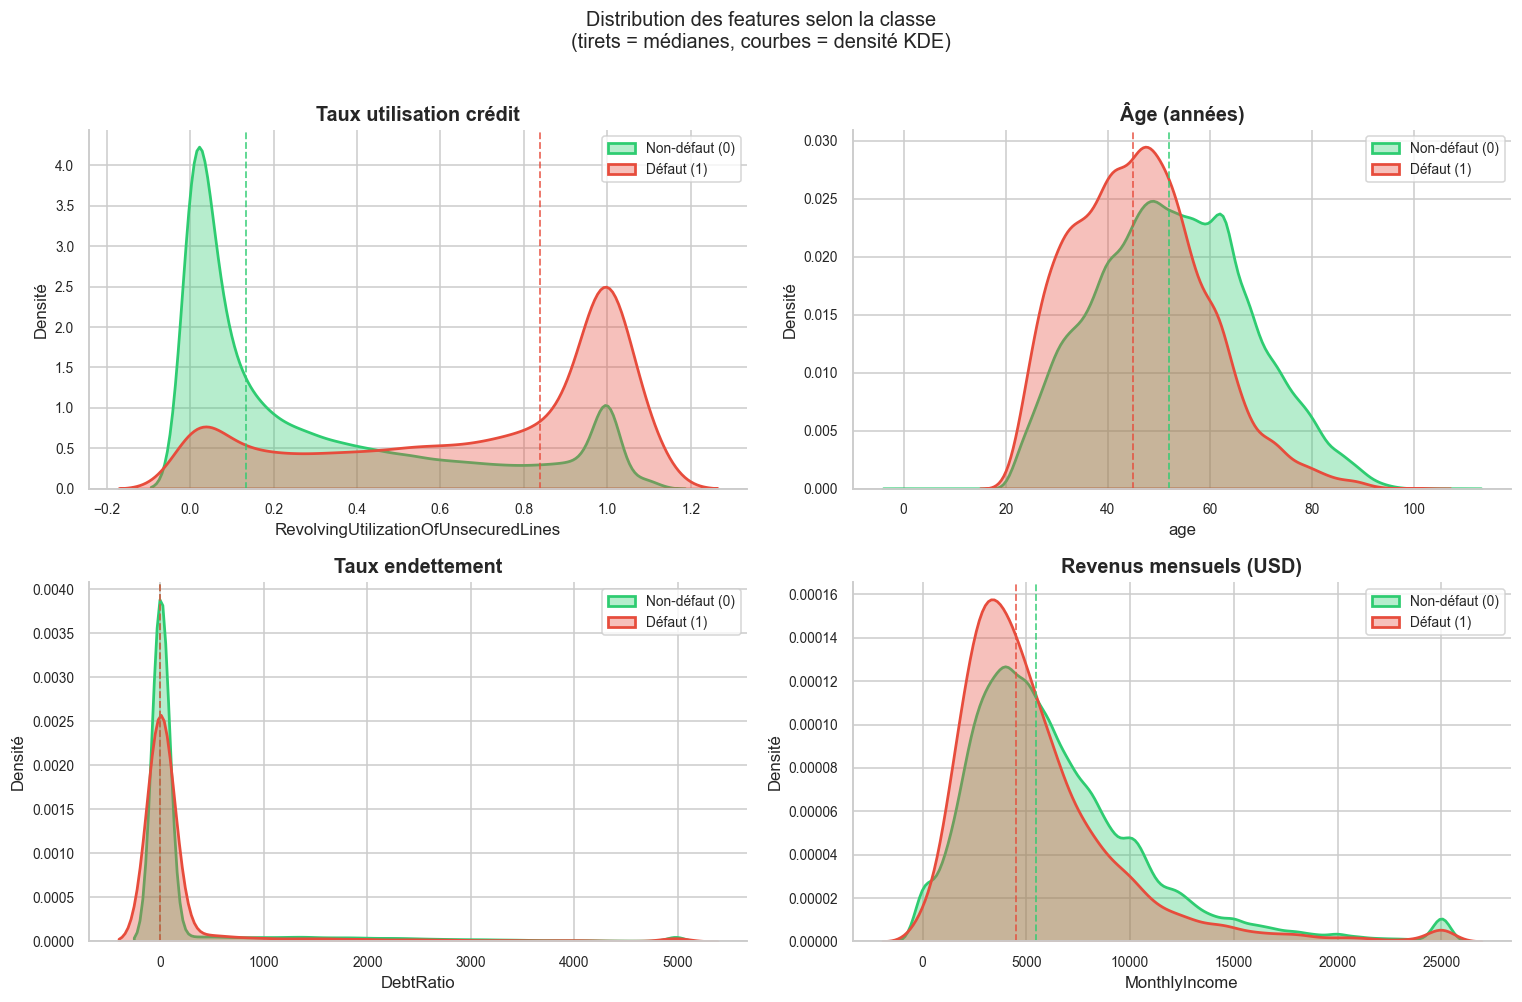

Figure sauvegardée : ./figures/fig_06_distributions_by_class.png


In [38]:
# Capper les données pour la lisibilité des visualisations
df_plot = df.copy()
for col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']:
    df_plot[col] = df_plot[col].clip(upper=df_plot[col].quantile(0.99))

features_to_plot = [
    ('RevolvingUtilizationOfUnsecuredLines', 'Taux utilisation crédit'),
    ('age',                                  'Âge (années)'),
    ('DebtRatio',                            'Taux endettement'),
    ('MonthlyIncome',                        'Revenus mensuels (USD)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, features_to_plot):
    for val, color, lbl in [(0, COLORS['non_def'], 'Non-défaut (0)'),
                             (1, COLORS['ELEVE'],   'Défaut (1)')]:
        subset = df_plot[df_plot['SeriousDlqin2yrs'] == val][col].dropna()
        sns.kdeplot(subset, ax=ax, fill=True, alpha=0.35,
                    color=color, label=lbl, linewidth=1.8)
        ax.axvline(subset.median(), color=color, linestyle='--',
                   linewidth=1.2, alpha=0.8)

    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('Densité')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribution des features selon la classe\n(tirets = médianes, courbes = densité KDE)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./figures/fig_06_distributions_by_class.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : ./figures/fig_06_distributions_by_class.png")

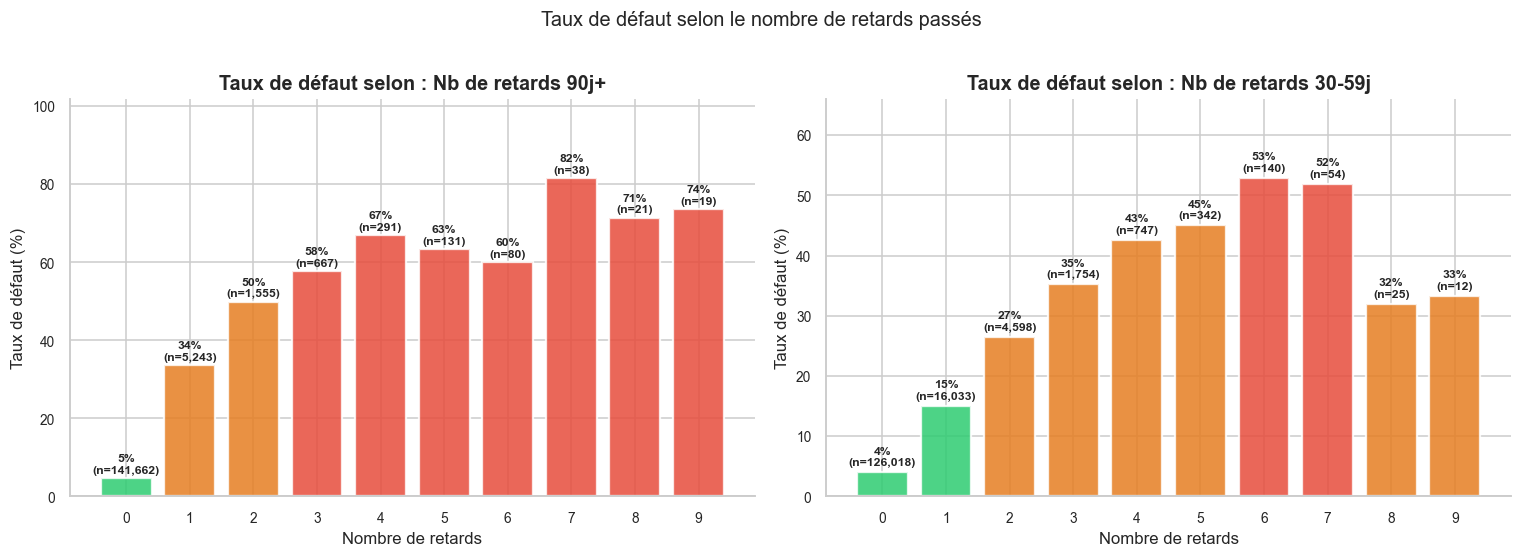

Figure sauvegardée : figures/fig_07_default_rate_by_delays.png


In [39]:
# Features discrètes — barplots du taux de défaut par valeur
discrete_vars = [
    ('NumberOfTimes90DaysLate',              'Nb de retards 90j+'),
    ('NumberOfTime30-59DaysPastDueNotWorse', 'Nb de retards 30-59j'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, label) in zip(axes, discrete_vars):
    # Exclure les sentinelles
    data_clean = df[df[col] < 10].copy()
    rates = data_clean.groupby(col)['SeriousDlqin2yrs'].agg(['mean', 'count'])
    rates['mean'] *= 100

    bars = ax.bar(rates.index.astype(str), rates['mean'],
                  color=[COLORS['non_def'] if r < 20 else COLORS['MOYEN'] if r < 50
                         else COLORS['ELEVE'] for r in rates['mean']],
                  alpha=0.85, edgecolor='white', linewidth=1.5)
    for bar, (idx, row) in zip(bars, rates.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.8,
                f'{row["mean"]:.0f}%\n(n={int(row["count"]):,})',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(f'Taux de défaut selon : {label}')
    ax.set_xlabel('Nombre de retards')
    ax.set_ylabel('Taux de défaut (%)')
    ax.set_ylim(0, rates['mean'].max() * 1.25)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Taux de défaut selon le nombre de retards passés', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_07_default_rate_by_delays.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : figures/fig_07_default_rate_by_delays.png")

### 8.1 Lecture des résultats

**Features continues :**
- `RevolvingUtilizationOfUnsecuredLines` : les clients en défaut ont un taux d'utilisation **nettement plus élevé**
- `MonthlyIncome` : les clients en défaut ont des revenus **nettement plus faibles**
- `age` : les clients en défaut sont en moyenne plus jeunes
- `DebtRatio` : différence moins nette car la colonne contient des outliers (corrigés à l'étape 5)

**Features discrètes (retards) :**
Le taux de défaut augmente **rapidement** avec le nombre de retards. Un seul retard de 90 jours élève significativement la probabilité de défaut. Ces features sont parmi les plus prédictives — elles seront cruciales dans la construction de la target à 3 niveaux.


---
## 9. Construction de la target à 3 niveaux de risque

### 9.1 Problème : le dataset est binaire, le projet veut 3 classes

Le dataset Kaggle fournit une target binaire : `SeriousDlqin2yrs = 0` ou `1`.  
Le cahier des charges Orus définit **3 niveaux de risque** : FAIBLE, MOYEN, ÉLEVÉ.

On doit donc **reconstruire la target** en utilisant la logique métier bancaire et les features de retards de paiement. Ce n'est pas du nettoyage de données — c'est une **décision de conception** qui doit être justifiée.

### 9.2 Logique de construction

La règle est la suivante, appliquée dans l'ordre de priorité :

| Règle | Niveau assigné | Justification |
|---|---|---|
| `SeriousDlqin2yrs == 1` **OU** `NumberOfTimes90DaysLate >= 2` | **ÉLEVÉ** | Défaut avéré ou retards graves multiples → risque réel et démontré |
| `NumberOfTime30-59DaysPastDueNotWorse >= 1` **OU** `DebtRatio > 0.5` | **MOYEN** | Signaux d'alerte présents sans défaut caractérisé |
| Tout le reste | **FAIBLE** | Aucun signal négatif → profil sain |

> **Pourquoi `DebtRatio > 0.5` comme seuil MOYEN ?**  
> Un taux d'endettement supérieur à 50% signifie que plus de la moitié des revenus servent à rembourser des dettes. C'est le seuil généralement reconnu en pratique bancaire comme signal de fragilité financière.


In [40]:
def construire_target(row):
    # Priorité 1 : ÉLEVÉ — défaut avéré ou retards graves multiples
    if row['SeriousDlqin2yrs'] == 1 or row['NumberOfTimes90DaysLate'] >= 2:
        return 'ELEVE'
    # Priorité 2 : MOYEN — signaux d'alerte
    if (row['NumberOfTime30-59DaysPastDueNotWorse'] >= 1 or
        row['DebtRatio'] > 0.5):
        return 'MOYEN'
    # Par défaut : FAIBLE
    return 'FAIBLE'

# Appliquer sur le dataset SANS les valeurs sentinelles
df_target = df.copy()
# Remplacer les 98 avant de construire la target (anticipation du preprocessing)
for col in delay_cols:
    df_target[col] = df_target[col].replace(98, np.nan)
    df_target[col] = df_target[col].fillna(df_target[col].median())

df_target['risque'] = df_target.apply(construire_target, axis=1)

dist = df_target['risque'].value_counts()
dist_pct = df_target['risque'].value_counts(normalize=True) * 100

print("Distribution de la nouvelle target à 3 classes :")
for niveau in ['FAIBLE', 'MOYEN', 'ELEVE']:
    n   = dist.get(niveau, 0)
    pct = dist_pct.get(niveau, 0)
    print(f"  {niveau:<6} : {n:>7,} clients  ({pct:.1f}%)")

Distribution de la nouvelle target à 3 classes :
  FAIBLE :  75,964 clients  (50.6%)
  MOYEN  :  62,743 clients  (41.8%)
  ELEVE  :  11,293 clients  (7.5%)


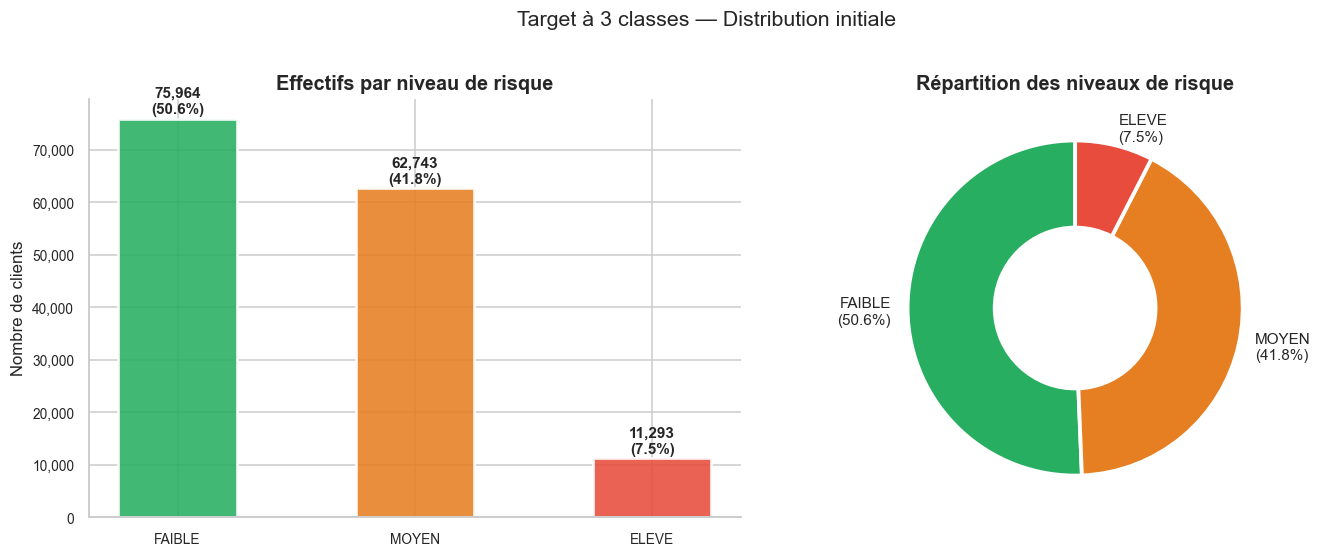

Figure sauvegardée : figures/fig_08_target_3classes.png


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ordre      = ['FAIBLE', 'MOYEN', 'ELEVE']
colors_3   = [COLORS['FAIBLE'], COLORS['MOYEN'], COLORS['ELEVE']]
counts_3   = [dist.get(n, 0) for n in ordre]
pcts_3     = [dist_pct.get(n, 0) for n in ordre]

# ── Barplot ────────────────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(ordre, counts_3, color=colors_3, alpha=0.88,
               edgecolor='white', linewidth=1.8, width=0.5)
for bar, val, pct in zip(bars, counts_3, pcts_3):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 400,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_title('Effectifs par niveau de risque')
ax1.set_ylabel('Nombre de clients')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.spines[['top', 'right']].set_visible(False)

# ── Donut ──────────────────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts_3,
    labels=[f'{n}\n({p:.1f}%)' for n, p in zip(ordre, pcts_3)],
    colors=colors_3,
    startangle=90,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5),
    textprops={'fontsize': 10},
    autopct='',
)
ax2.set_title('Répartition des niveaux de risque')

plt.suptitle('Target à 3 classes — Distribution initiale', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_08_target_3classes.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : figures/fig_08_target_3classes.png")

### 9.3 Validation de la cohérence

On vérifie que la nouvelle target est cohérente avec la target originale : tous les clients `SeriousDlqin2yrs = 1` doivent être en niveau ÉLEVÉ.


In [42]:
# Vérification de cohérence
crosstab = pd.crosstab(df_target['SeriousDlqin2yrs'],
                        df_target['risque'],
                        margins=True)
print("Tableau croisé — target originale vs target 3 classes :")
print(crosstab)
print()

# Tous les défauts (1) doivent être ÉLEVÉ
defauts_non_eleves = df_target[
    (df_target['SeriousDlqin2yrs'] == 1) & (df_target['risque'] != 'ELEVE')
]
print(f"Défauts classés hors ÉLEVÉ : {len(defauts_non_eleves)} (doit être 0 ✓)")

Tableau croisé — target originale vs target 3 classes :
risque            ELEVE  FAIBLE  MOYEN     All
SeriousDlqin2yrs                              
0                  1267   75964  62743  139974
1                 10026       0      0   10026
All               11293   75964  62743  150000

Défauts classés hors ÉLEVÉ : 0 (doit être 0 ✓)


### 9.4 Le déséquilibre persiste — et c'est normal

La classe ÉLEVÉ reste minoritaire (~7-10%). C'est un reflet fidèle de la réalité bancaire : les clients à haut risque sont rares.  
On conserve les techniques d'équilibrage planifiées : `class_weight='balanced'` et SMOTE sur le train set.


---
## 10. Synthèse — Décisions de preprocessing

Ce tableau récapitule toutes les décisions prises sur la base de l'EDA. Chaque décision sera implémentée dans le **notebook 02 — Preprocessing**.

| # | Problème identifié | Décision | Justification |
|---|---|---|---|
| 1 | Déséquilibre 93%/7% | `class_weight='balanced'` + SMOTE sur train uniquement | Éviter qu'un modèle naïf ignore la classe défaut |
| 2 | `MonthlyIncome` : 19.8% manquant | Imputation par la médiane | Distribution skewed → médiane plus représentative que moyenne |
| 3 | `NumberOfDependents` : 2.6% manquant | Imputation par la médiane | Faible volume, même logique |
| 4 | `age == 0` : 1 ligne | Suppression | Erreur de saisie évidente — âge zéro impossible |
| 5 | `DebtRatio` max = 329 664 | Capping au percentile 99 | Valeur physiquement impossible |
| 6 | `RevolvingUtilizationOfUnsecuredLines` max = 50 708 | Capping au percentile 99 | Taux d'utilisation > 100% déjà anormal |
| 7 | Valeurs `98` dans colonnes retards | Remplacement par `NaN` puis imputation médiane | Valeurs sentinelles, pas de vraies données |
| 8 | Target binaire → 3 classes | Règle métier : ÉLEVÉ / MOYEN / FAIBLE | Alignement avec le cahier des charges Orus |
| 9 | Métriques d'évaluation | ROC-AUC + recall classe ÉLEVÉ | Accuracy inadaptée au déséquilibre de classes |

---

**Prochaine étape → Notebook 02 — Preprocessing**  
Implémentation de toutes ces décisions : nettoyage, imputation, encodage, scaling, construction de la target, et split train/validation/test.
